## 0 - Engenharia e Validação dos dados

In [342]:
# Importações blibliotecas
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

In [343]:
# Carregamento dos dados
hotel_data = pd.read_csv('../data/hotel_bookings.csv')

In [344]:
# Visualização dos dados
hotel_data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [345]:
# Visualização dos dados
hotel_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [346]:
# Visualização dos dados
hotel_data.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [347]:
# Verificando duplicatas
duplicated_rows = hotel_data.duplicated()
print(f"Número de linhas duplicadas: {duplicated_rows.sum()}")

# Verificando valores ausentes
missing_values = hotel_data.isnull().sum()
print(f"Valores ausentes por coluna: {missing_values.sum()} ")

Número de linhas duplicadas: 31994
Valores ausentes por coluna: 129425 


In [348]:
# Análisando as duplicatas
print(hotel_data.shape)

duplicated_rows = hotel_data[hotel_data.duplicated()]
print(duplicated_rows.head())

(119390, 32)
            hotel  is_canceled  lead_time  arrival_date_year  \
5    Resort Hotel            0         14               2015   
22   Resort Hotel            0         72               2015   
43   Resort Hotel            0         70               2015   
138  Resort Hotel            1          5               2015   
200  Resort Hotel            0          0               2015   

    arrival_date_month  arrival_date_week_number  arrival_date_day_of_month  \
5                 July                        27                          1   
22                July                        27                          1   
43                July                        27                          2   
138               July                        28                          5   
200               July                        28                          7   

     stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
5                          0                  

In [349]:
# Removendo as duplicatas
hotel_data_cleaned = hotel_data.drop_duplicates().reset_index(drop=True)
print("Nova dimensão do DataFrame após remoção de duplicatas:", hotel_data_cleaned.shape)

Nova dimensão do DataFrame após remoção de duplicatas: (87396, 32)


In [350]:
# Análisando os valores ausentes
missing_counts = hotel_data_cleaned.isnull().sum()
missing_percent = (hotel_data_cleaned.isnull().mean() * 100)

missing_table = pd.DataFrame({'missing_count': missing_counts,
                              'missing_percent': missing_percent}).sort_values('missing_percent', ascending=False)

print(missing_table[missing_table['missing_count'] > 0])

          missing_count  missing_percent
company           82137        93.982562
agent             12193        13.951439
country             452         0.517186
children              4         0.004577


In [351]:
# removendo as colunas com mais valores ausentes
hotel_data_cleaned = hotel_data_cleaned.drop(columns=['company'])

# preenchendo os valores ausentes da coluna 'agent' com 0
hotel_data_cleaned['agent'] = hotel_data_cleaned['agent'].fillna(0)

# preenchendo os valores ausentes da coluna 'children' com 0
hotel_data_cleaned['children'] = hotel_data_cleaned['children'].fillna(0)

# preenchendo os valores ausentes da coluna 'country' com 'Unknown'
hotel_data_cleaned['country'] = hotel_data_cleaned['country'].fillna('Unknown')

In [352]:
# Verificando novamente os valores ausentes
missing_counts_after = hotel_data_cleaned.isnull().sum()
print(f"Valores ausentes por coluna após tratamento: {missing_counts_after.sum()} ")

Valores ausentes por coluna após tratamento: 0 


In [353]:
# Verificando o tipo de dados das colunas
print(hotel_data_cleaned.dtypes)

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [354]:
# Padronizando as colunas
hotel_data_cleaned.columns = (hotel_data_cleaned.columns.str.strip()
                                                       .str.lower()
                                                       .str.replace(' ', '_'))

# Padronizar os dados
for col in hotel_data_cleaned.select_dtypes(include=['object', 'string']):
    hotel_data_cleaned[col] = hotel_data_cleaned[col].str.lower()

print(hotel_data_cleaned.columns)
print()
print(hotel_data_cleaned.head())

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  resort hotel            0        342               2015               july   
1  resort hotel            0        737               2015               july   
2  resort hotel            0          7          

Na etapa inicial foi realizada uma validação estrutural completa do dataset de reservas hoteleiras, com foco em garantir qualidade, consistência e confiabilidade estatística antes de qualquer modelagem.

O dataset original continha 119.390 registros e 32 colunas. Durante a auditoria, foram identificadas 31.994 linhas duplicadas, representando aproximadamente 27% da base. Essas duplicatas eram registros idênticos e, portanto, foram removidas. Após a limpeza, o dataset passou a conter 87.396 registros, reduzindo ruído e evitando viés estatístico.

Também foram identificados 129.425 valores ausentes, concentrados principalmente na coluna company (cerca de 94% de ausência), tornando-a candidata à remoção por baixa relevância informacional. Outras colunas como agent, country e children apresentaram níveis baixos ou moderados de ausência e foram tratadas com imputação adequada.

Além disso, foram realizadas:

Padronização dos nomes das colunas
Correção de tipos de dados
Verificação de consistência lógica
Estruturação adequada de variáveis temporais (quando aplicável)

## 1 - Análise Exploratória de Dados (EDA)

is_canceled
0    63371
1    24025
Name: count, dtype: int64


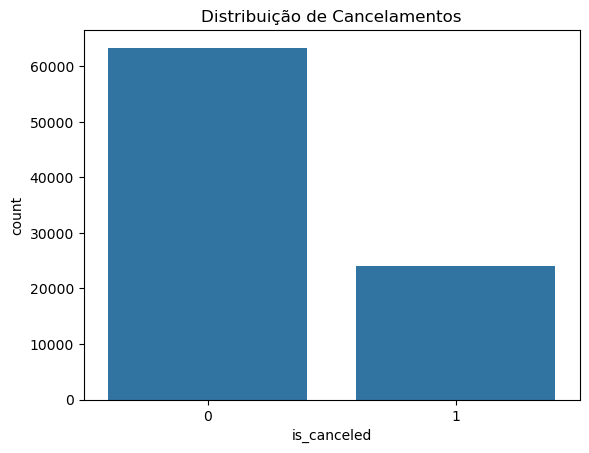

Taxa de cancelamento: 27.49%


In [355]:
# Availiando a distribuição de 'is_canceled'
print(hotel_data_cleaned['is_canceled'].value_counts())

# Visualizando a distribuição de 'is_canceled'
sns.countplot(x='is_canceled', data=hotel_data_cleaned)
plt.title('Distribuição de Cancelamentos')
plt.show()

# Avaliando a media de 'is_canceled'
cancellation_rate = hotel_data_cleaned['is_canceled'].mean()
print(f"Taxa de cancelamento: {cancellation_rate:.2%}")

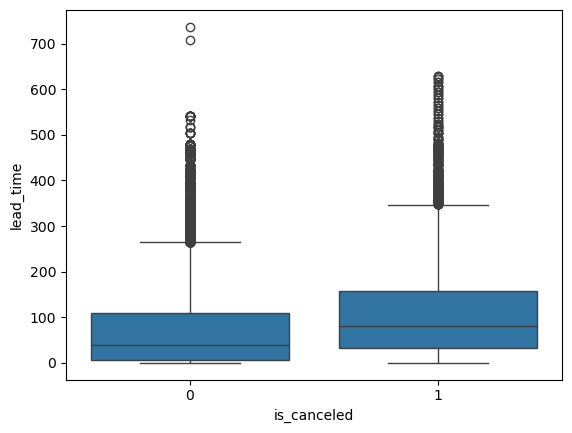

In [356]:
# Análise numérica x Cancelamento 'lead_time'
sns.boxplot(x='is_canceled', y='lead_time', data=hotel_data_cleaned)
plt.show()

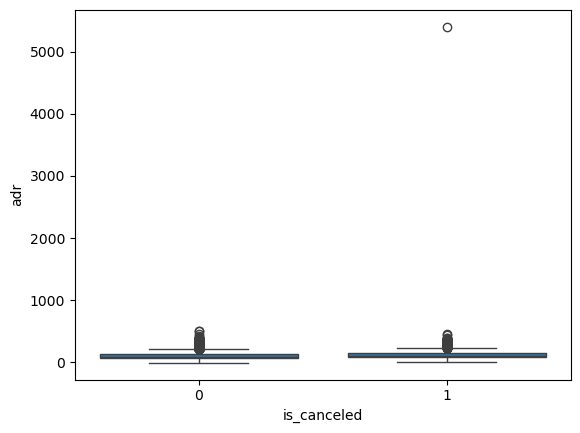

In [357]:
# Análise numérica x Cancelamento 'Adr'
sns.boxplot(x='is_canceled', y='adr', data=hotel_data_cleaned)
plt.show()

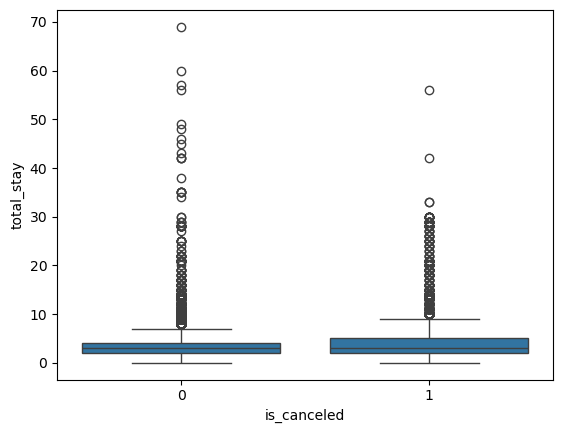

In [358]:
# Análise numérica x Cancelamento 'Duração da estadia'
hotel_data_cleaned['total_stay'] = hotel_data_cleaned['stays_in_weekend_nights'] + hotel_data_cleaned['stays_in_week_nights']

sns.boxplot(x='is_canceled', y='total_stay', data=hotel_data_cleaned)
plt.show()

In [359]:
# Variáveis categóricas 'Tipo de hotel'
pd.crosstab(hotel_data_cleaned['hotel'], hotel_data_cleaned['is_canceled'], normalize='index')

# Variáveis categóricas 'Canal de vendas'
pd.crosstab(hotel_data_cleaned['market_segment'], hotel_data_cleaned['is_canceled'], normalize='index')

# Variáveis categóricas 'Tipo de depósito'
pd.crosstab(hotel_data_cleaned['deposit_type'], hotel_data_cleaned['is_canceled'], normalize='index')

# Padrão temporal
cancel_by_month = pd.crosstab(hotel_data_cleaned['arrival_date_month'], hotel_data_cleaned['is_canceled'], normalize='index')

print(cancel_by_month)

is_canceled                0         1
arrival_date_month                    
april               0.695372  0.304628
august              0.678156  0.321844
december            0.731436  0.268564
february            0.767957  0.232043
january             0.778820  0.221180
july                0.682013  0.317987
june                0.696845  0.303155
march               0.756422  0.243578
may                 0.707720  0.292280
november            0.788989  0.211011
october             0.763196  0.236804
september           0.754559  0.245441


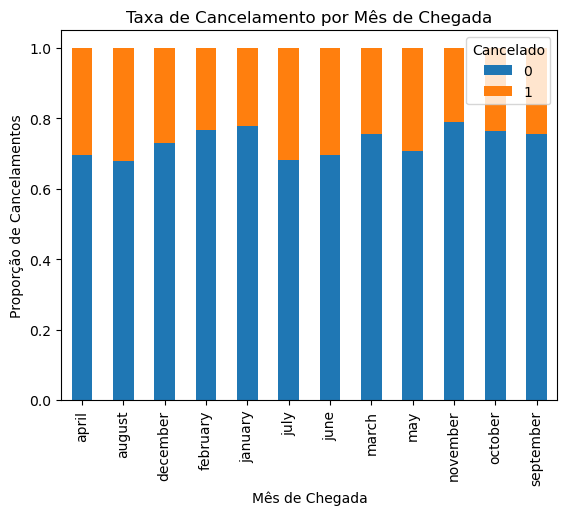

In [360]:
# Gráfico de cancelamento por mês em porcentagem
cancel_by_month.plot(kind='bar', stacked=True)
plt.title('Taxa de Cancelamento por Mês de Chegada')
plt.xlabel('Mês de Chegada')
plt.ylabel('Proporção de Cancelamentos')
plt.legend(title='Cancelado')
plt.show()

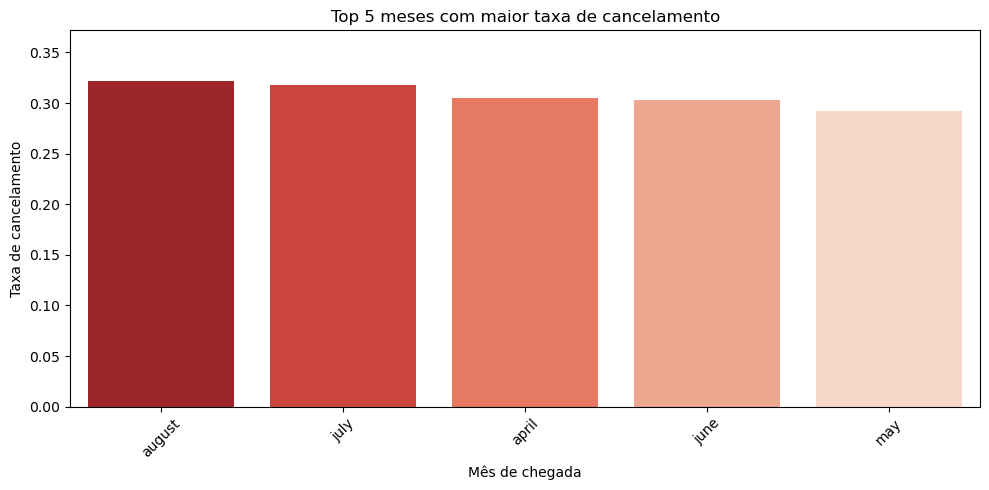

In [361]:
# Top 5 meses com maior taxa de cancelamento
top_5_cancel_months = (cancel_by_month[1]
                     .sort_values(ascending=False)
                      .head(5)
                      .reset_index(name='cancel_rate'))

plt.figure(figsize=(10, 5))
sns.barplot(data=top_5_cancel_months, x='arrival_date_month', y='cancel_rate', hue='arrival_date_month', palette='Reds_r', legend=False)
plt.title('Top 5 meses com maior taxa de cancelamento')
plt.xlabel('Mês de chegada')
plt.ylabel('Taxa de cancelamento')
plt.ylim(0, top_5_cancel_months['cancel_rate'].max() + 0.05)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Neste capítulo foi realizada a exploração do dataset com foco exclusivo em compreender o comportamento da variável **is_canceled** e identificar padrões relevantes.

A taxa de cancelamento encontrada foi de **27,49%**, indicando que pouco mais de um quarto das reservas são canceladas. O problema apresenta leve desbalanceamento, mas não em nível crítico.

Foram analisadas variáveis numéricas e categóricas para identificar possíveis relações com o cancelamento. Observou-se que:

Reservas com maior **lead_time** tendem a apresentar maior probabilidade de cancelamento.

O **adr (preço médio da diária)** apresenta variação entre reservas canceladas e não canceladas.

A duração da estadia **total_stay** foi avaliada para verificar impacto no comportamento do cliente.

Variáveis como tipo de hotel, segmento de mercado e tipo de depósito demonstraram diferenças relevantes entre os grupos.

A análise por mês revelou padrão sazonal, com variações significativas na taxa de cancelamento ao longo do ano.

De forma geral, o capítulo permitiu identificar padrões comportamentais e variáveis com potencial explicativo, fornecendo entendimento analítico do problema antes da etapa de modelagem.

## 2 - Preparação dos Dados para Modelagem

In [362]:
# Remover variáveis com risco de Data Leakage(vazamento de dados)
# Variáveis que não podem ir para o modelo
columns_to_drop = ['reservation_status', 'reservation_status_date']

hotel_model = hotel_data_cleaned.drop(columns=columns_to_drop)

In [363]:
# Separando as variáveis independentes X e Alvo y
X = hotel_model.drop('is_canceled', axis=1)
y = hotel_model['is_canceled']

In [364]:
# Identificar as colunas numéricas e categóricas
columns_numeric = X.select_dtypes(include=['int64', 'float64']).columns
columns_categorical = X.select_dtypes(include=['object']).columns


In [365]:
# Aplicar One-Hot Encoding para as variáveis categóricas
X = pd.get_dummies(X, columns=columns_categorical, drop_first=True)

In [366]:
# Divisão dos dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

train_columns = X_train.columns

In [367]:
# Padronizar as variáveis numéricas
scaler = StandardScaler()

X_train[columns_numeric] = scaler.fit_transform(X_train[columns_numeric])
X_test[columns_numeric] = scaler.transform(X_test[columns_numeric])


In [368]:
# Verificação das formas dos conjuntos de treino e teste
print(f'Formato X_train: {X_train.shape}')
print(f'Formato X_test: {X_test.shape}')
print(f'Proporção de cancelamento no treino: {y_train.mean():.2%}')
print(f'Proporção de cancelamento no teste: {y_test.mean():.2%}')

Formato X_train: (69916, 248)
Formato X_test: (17480, 248)
Proporção de cancelamento no treino: 27.49%
Proporção de cancelamento no teste: 27.49%


Nesta etapa o dataset foi estruturado para ser utilizado em modelos de Machine Learning.

Inicialmente, foram removidas variáveis com risco de **data leakage**, como **reservation_status** e **reservation_status_date**, pois contêm informações que só existem após o desfecho da reserva e poderiam comprometer a validade do modelo.

Em seguida, os dados foram organizados em variáveis independentes (X) e variável alvo (y), sendo **is_canceled** definida como target. As variáveis categóricas foram transformadas em formato numérico por meio de One-Hot Encoding, garantindo compatibilidade com algoritmos supervisionados.

Posteriormente, o conjunto de dados foi dividido em treino e teste, preservando a proporção original de cancelamentos (**27,49%**) por meio da técnica de estratificação. Por fim, as variáveis numéricas foram padronizadas utilizando **StandardScaler**, assegurando que todas estivessem na mesma escala e evitando distorções em modelos sensíveis à magnitude dos dados.

Ao final desta etapa, o dataset ficou limpo, estruturado e adequado para a aplicação dos primeiros modelos de classificação.

## 3 - Modelagem Inicial (Primeiro Modelo Base)

In [369]:
# Treinar o modelo de Regressão Logística
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [370]:
# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [371]:
# Avaliação do modelo
print('Matriz de Confusão:')
print(confusion_matrix(y_test, y_pred))
print()

print('Relatório de Classificação:')
print(classification_report(y_test, y_pred))
print()

print('ROC AUC Score:')
print(roc_auc_score(y_test, y_prob))

Matriz de Confusão:
[[11572  1103]
 [ 2487  2318]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.82      0.91      0.87     12675
           1       0.68      0.48      0.56      4805

    accuracy                           0.79     17480
   macro avg       0.75      0.70      0.71     17480
weighted avg       0.78      0.79      0.78     17480


ROC AUC Score:
0.8442438452713006


### 3.1 - Treinar novamente o modelo e ajustar o peso da classe

In [372]:
# Treinar um modelo com ajuste de classe para lidar com o desbalanceamento
balanced_model = LogisticRegression(max_iter=1000,
                                    random_state=42,
                                    class_weight='balanced')

balanced_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [373]:
# Fazendo previsões no conjunto de teste
y_balanced_pred = balanced_model.predict(X_test)
y_balanced_prob = balanced_model.predict_proba(X_test)[:, 1]

In [374]:
# Avaliar o desempenho do modelo
print('Matriz de Confusão')
print(confusion_matrix(y_test, y_balanced_pred))
print()

print('Relatório de Classificação')
print(classification_report(y_test, y_balanced_pred))
print()

print('ROC AUC Score:')
print(roc_auc_score(y_test, y_balanced_prob))

Matriz de Confusão
[[9296 3379]
 [ 984 3821]]

Relatório de Classificação
              precision    recall  f1-score   support

           0       0.90      0.73      0.81     12675
           1       0.53      0.80      0.64      4805

    accuracy                           0.75     17480
   macro avg       0.72      0.76      0.72     17480
weighted avg       0.80      0.75      0.76     17480


ROC AUC Score:
0.8452003439875049


Nesta etapa foi iniciado o processo de modelagem preditiva com o objetivo de construir um modelo capaz de prever o cancelamento de reservas. A **Regressão Logística** foi escolhida como modelo baseline por sua interpretabilidade e estabilidade em problemas de classificação binária.

No primeiro modelo, sem ajuste de pesos, foi obtida uma **acurácia de 79%** e **ROC-AUC de 0,84**, indicando boa capacidade de separação entre reservas canceladas e não canceladas. Entretanto, o **recall da classe de cancelamentos foi de 48%**, o que significa que mais da metade dos cancelamentos reais não foram identificados. Embora o modelo apresentasse bom desempenho geral, sua capacidade de capturar cancelamentos era limitada.

Na etapa seguinte, foi aplicado o parâmetro **class_weight='balanced**, ajustando automaticamente o peso da classe minoritária. Com essa modificação, o **recall dos cancelamentos aumentou significativamente para 80%**, reduzindo consideravelmente os falsos negativos. Em contrapartida, houve aumento de falsos positivos e a **acurácia geral caiu para 75%**. O **ROC-AUC permaneceu praticamente inalterado (0,845)**, indicando que a capacidade de discriminação do modelo se manteve consistente.

De forma geral, **a segunda abordagem demonstrou melhor desempenho na identificação de cancelamentos**, tornando-se mais adequada caso o objetivo estratégico seja minimizar perdas associadas a reservas canceladas. Essas duas etapas permitiram estabelecer uma base comparativa sólida para decisões futuras sobre otimização do modelo.


## 4 - Teste de um modelo mais robusto (Random Forest)

In [375]:
# Classificadondo o Random Forest
random_forest_model = RandomForestClassifier(n_estimators=200,
                                             random_state=42,
                                             class_weight='balanced')

In [376]:
# Treinar o modelo de Random Forest
random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]


In [377]:
# Teste de desempenho do modelo Random Forest
print('Matriz de Confusão')
print(confusion_matrix(y_test, y_pred_rf))
print()

print('Relatório de Classificação')
print(classification_report(y_test, y_pred_rf))
print()

print('ROC AUC Score:')
print(roc_auc_score(y_test, y_prob_rf))

Matriz de Confusão
[[11796   879]
 [ 1783  3022]]

Relatório de Classificação
              precision    recall  f1-score   support

           0       0.87      0.93      0.90     12675
           1       0.77      0.63      0.69      4805

    accuracy                           0.85     17480
   macro avg       0.82      0.78      0.80     17480
weighted avg       0.84      0.85      0.84     17480


ROC AUC Score:
0.9093980506006439


Nesta etapa foi implementado o modelo Random Forest com o objetivo de avaliar se um algoritmo não linear apresentaria melhor desempenho em relação à Regressão Logística.

O modelo obteve **85% de acurácia** e **ROC-AUC de 0,91**, indicando excelente capacidade de separação entre reservas canceladas e não canceladas. Em comparação com os modelos anteriores, houve ganho expressivo na performance geral.

No que se refere à classe de cancelamentos, o modelo apresentou **recall de 63%**, superando a Regressão Logística inicial (48%), embora abaixo do modelo balanceado (80%). Por outro lado, alcançou **precision de 77%**, demonstrando maior confiabilidade nas previsões de cancelamento e redução significativa de falsos positivos.

De forma geral, o Random Forest mostrou melhor equilíbrio entre precisão e capacidade preditiva, além de apresentar a maior capacidade de discriminação entre as classes. Essa etapa consolidou o modelo como a abordagem mais robusta até o momento do projeto, servindo como base para ajustes e otimizações futuras.


### 4.1 - Extraindo a importância das Variáveis

In [378]:
# Análise de importância das variáveis no modelo Random Forest
importances = pd.DataFrame({'variavel': X_train.columns,
                            'importancia': random_forest_model.feature_importances_})

# Ordernar da mais importante para a menos importante
importances = importances.sort_values(by='importancia', ascending=False)

# Visualizar as 10 variáveis mais importantes
print(importances.head(10))

                        variavel  importancia
0                      lead_time     0.120435
15                           adr     0.076387
3      arrival_date_day_of_month     0.056980
169                  country_prt     0.056383
13                         agent     0.052199
2       arrival_date_week_number     0.051594
17     total_of_special_requests     0.050040
16   required_car_parking_spaces     0.038933
18                    total_stay     0.036157
5           stays_in_week_nights     0.032832


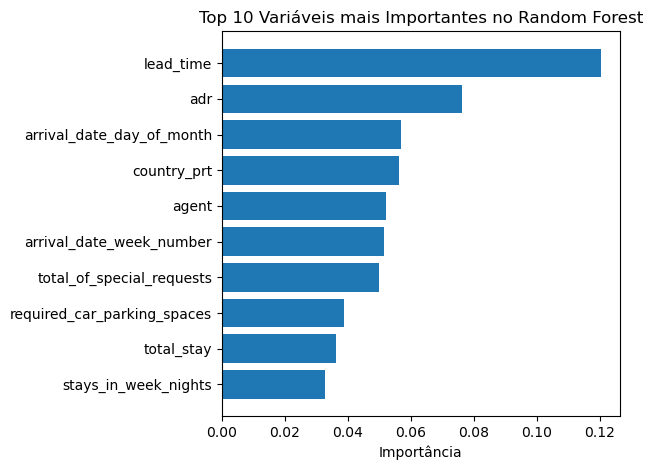

In [379]:
# Visualização Gráfica das 10 variáveis mais importantes
top10 = importances.head(10)

plt.figure()
plt.barh(top10['variavel'], top10['importancia'])
plt.gca().invert_yaxis() # Inverter o eixo y para mostrar a variável mais importante no topo
plt.xlabel('Importância')
plt.title('Top 10 Variáveis mais Importantes no Random Forest')
plt.tight_layout()
plt.show()


A análise de importância das variáveis demonstra que o cancelamento de reservas é influenciado principalmente por fatores comportamentais, financeiros e sazonais. A variável com maior impacto no modelo foi o **lead time**, indicando que quanto maior a antecedência entre a data da reserva e a data de chegada, maior a probabilidade de cancelamento. Esse resultado sugere que clientes que reservam com muita antecedência possuem mais tempo para alterar seus planos, aumentando o risco de desistência.

Em seguida, o **ADR (Average Daily Rate)** aparece como a segunda variável mais relevante, evidenciando que o preço da diária exerce influência significativa sobre a decisão de cancelar. Valores mais elevados tendem a aumentar a sensibilidade do cliente, o que pode elevar a taxa de cancelamento.

As variáveis relacionadas à **sazonalidade**, como dia do mês e semana do ano de chegada, também apresentam importância considerável, indicando que o comportamento de cancelamento varia ao longo do calendário. Isso sugere que determinados períodos concentram maior instabilidade nas reservas, possivelmente associados a características de demanda, eventos ou perfil do público.

A variável referente ao **país de origem (country_prt)** aponta que clientes do mercado doméstico apresentam padrão distinto de cancelamento, o que reforça a necessidade de segmentação geográfica na análise. Além disso, o **agente de reserva (agent)** também possui relevância significativa, indicando que o canal de aquisição influencia a qualidade da reserva e o risco associado ao cancelamento.

Por fim, variáveis que indicam **nível de comprometimento do cliente**, como número de solicitações especiais, necessidade de vaga de estacionamento e duração total da estadia, também contribuem para explicar o fenômeno. Esses fatores sugerem que clientes mais engajados e com planejamento mais estruturado tendem a apresentar menor probabilidade de cancelamento.

De forma geral, o modelo evidencia que o cancelamento está mais associado a aspectos comportamentais, de preço e contexto temporal do que a características demográficas isoladas, oferecendo direcionamentos claros para estratégias de precificação, segmentação e políticas de reserva.


## 5 - Construir uma simulação de impacto operacional e financeiro

In [380]:
# Gerar probabilidade e Risk Score
# Probabilidade para base completa
hotel_data_cleaned['prob_cancelamento'] = random_forest_model.predict_proba(X)[:, 1]

# Segmentação de risco
hotel_data_cleaned['risk_level'] = pd.cut(hotel_data_cleaned['prob_cancelamento'],
                                          bins=[0, 0.3, 0.6, 1],
                                          labels=['Baixo', 'Médio', 'Alto'])


In [381]:
# Calculo financeiro Atual
# Receita prevista por reserva
hotel_data_cleaned['receita_prevista'] = hotel_data_cleaned['adr'] * hotel_data_cleaned['total_stay']

# Receita perdida real
hotel_data_cleaned['receita_perdida'] = hotel_data_cleaned['receita_prevista'] * hotel_data_cleaned['is_canceled']

total_receita = hotel_data_cleaned['receita_prevista'].sum()
lost_receita = hotel_data_cleaned['receita_perdida'].sum()
lost_percent = lost_receita / total_receita * 100

print('Receita total potencial:', round(total_receita, 2))
print('Receita perdida por cancelamento:', round(lost_receita, 2))
print('% de perda:', round(lost_percent, 2), '%')

Receita total potencial: 34460939.31
Receita perdida por cancelamento: 11484042.98
% de perda: 33.32 %


In [382]:
# Simulação de política de mitigação
hight_risk = hotel_data_cleaned[hotel_data_cleaned['risk_level'] == 'Alto']

hight_cancel = hight_risk['is_canceled'].sum()

# Simulação
percent_reduc = 0.30
cancel_evit = hight_cancel * percent_reduc

receita_media_alta = hight_risk['receita_prevista'].mean()

receita_recup = cancel_evit * receita_media_alta

print('Cancelamentos alto risco:', hight_cancel)
print('Cancelamentos evitáveis:', round(cancel_evit, 2))
print('Receita potencial recuperada:', round(receita_recup, 2))



Cancelamentos alto risco: 2444
Cancelamentos evitáveis: 733.2
Receita potencial recuperada: 444797.79


In [383]:
# Novo cenário financeiro simulado
new_lost_receita = lost_receita - receita_recup
new_percent_lost = new_lost_receita / total_receita * 100

print('Nova receita perdida:', round(new_lost_receita, 2))
print('Novo % de perda:', round(new_percent_lost, 2), '%')

Nova receita perdida: 11039245.19
Novo % de perda: 32.03 %


In [384]:
# Overbooking beseado em probabilidade
cancel_esperados = hotel_data_cleaned['prob_cancelamento'].sum()

print('Cancelamentos esperados:', round(cancel_esperados, 2))

Cancelamentos esperados: 29461.24


In [385]:
print("\n===== RESUMO EXECUTIVO =====")
print(f"Receita Total Potencial: {total_receita:,.2f}")
print(f"Receita Perdida Atual: {lost_receita:,.2f}")
print(f"Impacto Atual: {lost_percent:.2f}%")

print(f"\nReceita Recuperável (Simulação): {receita_recup:,.2f}")
print(f"Nova Receita Perdida: {new_lost_receita:,.2f}")
print(f"Novo Impacto: {new_percent_lost:.2f}%")

print(f"\nCancelamentos Esperados (Modelo): {cancel_esperados:.0f}")


===== RESUMO EXECUTIVO =====
Receita Total Potencial: 34,460,939.31
Receita Perdida Atual: 11,484,042.98
Impacto Atual: 33.32%

Receita Recuperável (Simulação): 444,797.79
Nova Receita Perdida: 11,039,245.19
Novo Impacto: 32.03%

Cancelamentos Esperados (Modelo): 29461


## 6 - Criação do Motor de Decisão

In [386]:
# Função principal do sistema de decisão
def decision_engine(hotel_data_cleaned, prob_col='prob_cancelamento'):
    hotel_data_cleaned = hotel_data_cleaned.copy()

In [387]:
# Classificação de risco
hotel_data_cleaned['risk_level'] = np.where(hotel_data_cleaned['prob_cancelamento'] >= 0.70, 'Alto',
                                            np.where(hotel_data_cleaned['prob_cancelamento'] >= 0.40, 'Médio', 'Baixo'))

In [388]:
# Ações Operacionais
def get_action(row):
    if row['risk_level'] == 'Alto':
        return 'Overbooking + Retenção ativa + Oferta estratégica'
    
    elif row['risk_level'] == 'Médio':
        return 'Reconfirmação automática + monitoramento'
    
    else:
        return 'Sem ação (fluxo normal)'
    
    hotel_data_cleaned['acao_recomendada'] = hotel_data_cleaned.apply(get_action, axis=1)

    return hotel_data_cleaned

### 6.1 - Camada Econômica (Decisão baseada em dinheiro)

In [389]:
# Impacto esperado por ação
def estimate_financial_impact(hotel_data_cleaned):
    
    hotel_data_cleaned = hotel_data_cleaned.copy()
    
    # Receita estimada
    hotel_data_cleaned['receita_estimada'] = hotel_data_cleaned['adr'] * hotel_data_cleaned['total_stay']
    
    # Fator de recuperação por risco
    hotel_data_cleaned['fator_recuperacao'] = np.where(
        hotel_data_cleaned['risk_level'] == 'Alto', 0.30,
        np.where(hotel_data_cleaned['risk_level'] == 'Médio', 0.10, 0.02)
    )
    
    # Ganho esperado
    hotel_data_cleaned['ganho_esperado'] = hotel_data_cleaned['receita_estimada'] * hotel_data_cleaned['fator_recuperacao']
    
    return hotel_data_cleaned

### 6.2 - Estrutura do Pipeline final

In [390]:
def run_full_pipeline(data, model):

    hotel_data_cleaned = data.copy()

    # Features engineering
    hotel_data_cleaned['total_stay'] = hotel_data_cleaned['stays_in_weekend_nights'] + hotel_data_cleaned['stays_in_week_nights']

    # Probabilidade
    X = hotel_data_cleaned.drop(columns=['is_canceled'], errors='ignore')
    X = pd.get_dummies(X, drop_first=True)

    # Alinhamento com treino
    X = X.reindex(columns=train_columns, fill_value=0)

    hotel_data_cleaned['prob_cancelamento'] = model.predict_proba(X)[:, 1]

    # Risco
    hotel_data_cleaned['risk_level'] = np.where(hotel_data_cleaned['prob_cancelamento'] >= 0.7, 'Alto',
                                                np.where(hotel_data_cleaned['prob_cancelamento'] >= 0.4, 'Médio', 'Baixo'))
    
    # Decisão
    hotel_data_cleaned['acao'] = np.where(hotel_data_cleaned['risk_level'] == 'Alto', 'Overbooking + retenção',
                                          np.where(hotel_data_cleaned['risk_level'] == 'Médio', 'Reconfiguração', 'Sem ação'))
    
    # Financeiro
    hotel_data_cleaned['receita'] = hotel_data_cleaned['adr'] * hotel_data_cleaned['total_stay']

    hotel_data_cleaned['fator'] = np.where(hotel_data_cleaned['risk_level'] == 'Alto', 0.30,
                                           np.where(hotel_data_cleaned['risk_level'] == 'Médio', 0.10, 0.02))
    
    hotel_data_cleaned['ganho_esperado'] = hotel_data_cleaned['receita'] * hotel_data_cleaned['fator']

    # Resumo
    resumo = {'receita_total': hotel_data_cleaned['receita'].sum(),
              'receita_perdida': (hotel_data_cleaned['receita'] * hotel_data_cleaned['is_canceled']).sum(),
              'ganho_sistema': hotel_data_cleaned['ganho_esperado'].sum(),
              'cancelamentos_previstos': hotel_data_cleaned['prob_cancelamento'].sum()
              }
    
    return hotel_data_cleaned, resumo

In [ ]:
# Executar o sistema
hotel_data_cleaned, resumo = run_full_pipeline(hotel_data_cleaned, random_forest_model)

In [392]:
# Relatório final
print("\n===== SISTEMA FINAL DE REVENUE MANAGEMENT =====")
print(f"Receita Total: {resumo['receita_total']:,.2f}")
print(f"Receita Perdida: {resumo['receita_perdida']:,.2f}")
print(f"Ganho com Sistema: {resumo['ganho_sistema']:,.2f}")
print(f"Cancelamentos Previstos: {resumo['cancelamentos_previstos']:.0f}")


===== SISTEMA FINAL DE REVENUE MANAGEMENT =====
Receita Total: 34,460,939.31
Receita Perdida: 11,484,042.98
Ganho com Sistema: 1,738,584.42
Cancelamentos Previstos: 29461


In [ ]:
# Salvar o arquivo
hotel_data_cleaned.to_csv("hotel_data_final.csv", index=False)